# Working with Data in PyTorch and torchvision

3: Working with Data in PyTorch

Dr. Atle E. Rimehaug

## Setup

### Import Libraries

In [1]:
import torch
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Section 1: Download Standard Datasets from Torchvision

| Code | Description |
|------------------------------------|------------------------------------|
| `datasets.CIFAR100(root="<data_dir>", download=True)` | Downloads the CIFAR100 image dataset and puts it in the directory specified by the `root` parameter. |
| `image, label = cifar10_data[5]` | Get the image and the label of the image at index number `5` |
| `plt.imshow(image)` | Display the image. |

<span class="theorem-title">**Example 1**</span> Download the MNIST
dataset, which contains images of handdrawn digits.

In [2]:
mnist_data = datasets.MNIST(
    root="data/raw",
    download=True,
)
mnist_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/raw
    Split: Train

In [3]:
idx_image = 1
image, label = mnist_data[idx_image]

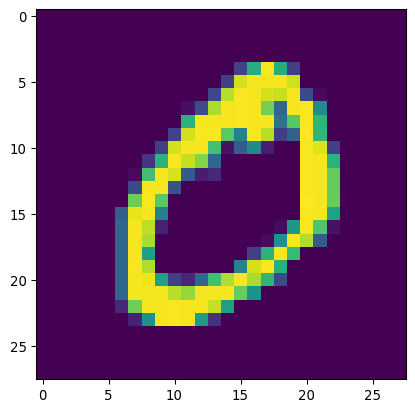

In [4]:
plt.imshow(image)

## Section 2: Transforming Data (normalize)

| Code | Description |
|------------------------------------|------------------------------------|
| `datasets.CIFAR10("data/raw",transform=transforms.ToTensor())` | `transforms.ToTensor()` converts PIL images or numpy arrays to tensors and scales the data so that all pixel values are within a range from 0 to 1. |

In [5]:
cifar10_data = datasets.CIFAR10(
    root="data/raw",
    download=True,
    transform=transforms.ToTensor(),
)
cifar10_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data/raw
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
idx_image = 7
image, label = cifar10_data[idx_image]

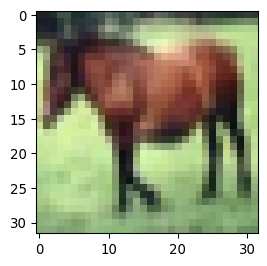

In [7]:
plt.figure(figsize = (3,3))
plt.imshow(image.permute(1,2,0))

In [8]:
label

7

## Section 3: Batch Data with Dataloaders

| Code | Description |
|------------------------------------|------------------------------------|
| `datasets.CIFAR10(root='data/raw', train=True)` | Load the **training** data of the CIFAR10 dataset. |
| `datasets.CIFAR10(root='data/raw', train=False)` | Load the **test** data of the CIFAR10 dataset. |
| `DataLoader(train_data, batch_size = 64)` | Create a dataloader object to be used for loading and iterating over dataset during training. `batch_size` sets how many data points are loaded together in each iteration, default value is 1. |

In [9]:
train_data = datasets.CIFAR10(root='data/raw', train=True, transform=transforms.ToTensor())
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data/raw
    Split: Train
    StandardTransform
Transform: ToTensor()

<span class="theorem-title">**Example 2**</span> Get the training data
of the CIFAR10 dataset and normalize it.

In [10]:
mean_cifar10 = (0.4914, 0.4822, 0.4465)
std_cifar10 = (0.2023, 0.1994, 0.2010)

# NOTE: Look up how the mean and std values for normalization are calculated exactly. Simply mean and std across all pixels and images in dataset?
train_data = datasets.CIFAR10(
    root="data/raw",
    train=True,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_cifar10, std_cifar10)
    ])
)

In [11]:
test_data = datasets.CIFAR10(root="data/raw",train=False)
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data/raw
    Split: Test

In [12]:
train_dataloader = DataLoader(train_data, batch_size=64)
train_dataloader

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3199205..2.4559333].

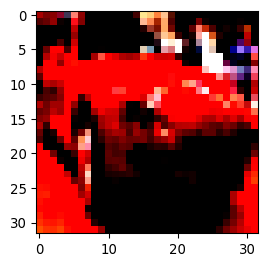

In [13]:
batch_images, batch_labels = next(iter(train_dataloader))
plt.figure(figsize=(3,3))
plt.imshow(batch_images[5].permute(1,2,0))

## Section 4: Prepare Your Own Data for PyTorch

| Code | Description |
|------|-------------|
| \`\` |             |

In [14]:
class WineDataset(Dataset):
    def __init__(self):
        # load data
        df = pd.read_csv('data/raw/wine.csv')
        self.n_samples = len(df)

        self.x_data = torch.from_numpy(df.drop('Wine', axis=1).values)
        self.y_data = torch.from_numpy(np.expand_dims(df['Wine'].values, axis=1))

    def __len__(self):
        return self.n_samples
    
    def __getitem__(self,index):
        return self.x_data[index], self.y_data[index]

In [15]:
wine_data = WineDataset()
wine_data

In [16]:
dataloader = DataLoader(wine_data)
dataloader

In [17]:
# split into train, validation, and test data?

In [18]:
feature, label = next(iter(dataloader))
feature, label

(tensor([[1.4230e+01, 1.7100e+00, 2.4300e+00, 1.5600e+01, 1.2700e+02, 2.8000e+00,
          3.0600e+00, 2.8000e-01, 2.2900e+00, 5.6400e+00, 1.0400e+00, 3.9200e+00,
          1.0650e+03]], dtype=torch.float64),
 tensor([[1]]))

In [19]:
import pandas as pd

df = pd.read_csv('data/raw/wine.csv')
np.expand_dims(df['Wine'].values, axis=1)
df

178 rows × 14 columns

In [20]:
import numpy as np
xy = np.loadtxt('data/raw/wine.csv', delimiter=',', dtype=np.float32, skiprows=1)
xy[:,1:]

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13), dtype=float32)

In [21]:
xy[:,[0]]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],

In [22]:
df.drop('Wine', axis=1).values

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))